# Desarrollo algoritmos para datos Yahoo! Music

## Librerias

In [1]:
# Entorno se reinicia, no hay que volver a ejecutar

!pip uninstall -y numpy
!pip install numpy==1.26

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.5/58.5 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.9/17.9 MB 53.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.0 which is incompatible.
tobler 0.13.0 requires numpy>=2.0, but you have numpy 1.26.0 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.0 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.0 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.0 which is incompatible.
music21 9.9.1 requires numpy>=1.26.4, but you have numpy 1.26.0 which is incompatible.
pytenso

In [1]:
!pip install gdown

In [2]:
!pip install scikit-surprise --no-build-isolation --no-deps

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.4/154.4 kB 3.8 MB/s eta 0:00:00
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp312-cp312-linux_x86_64.whl size=2708547 sha256=f3b7a1a294d5b42a3cdd022c434a667eb408bdcc9cd94e9a286bf4dc3259edeb
  Stored in directory: /root/.cache/pip/wheels/75/fa/bc/739bc2cb1fbaab6061854e6cfbb81a0ae52c92a502a7fa454b
Successfully built scikit-surprise


In [1]:
import surprise
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

from surprise.model_selection import PredefinedKFold
from surprise import BaselineOnly, Dataset, Reader,  NormalPredictor, accuracy

## Datos

In [ ]:
!unzip OneDrive_2026-03-25.zip
!mv -f Datasets\ Tarea\ \(p├║blico\) Datos

Archive:  OneDrive_2026-03-25.zip
 extracting: Datasets Tarea (p├║blico)/competicion_ranking.json  
 extracting: Datasets Tarea (p├║blico)/competicion_rating.txt  
 extracting: Datasets Tarea (p├║blico)/wikimedia_image_embeddings.npy  
 extracting: Datasets Tarea (p├║blico)/wikimedia_item_id_to_idx.npy  
 extracting: Datasets Tarea (p├║blico)/wikimedia_train.csv  
 extracting: Datasets Tarea (p├║blico)/wikimedia_validation.csv  
 extracting: Datasets Tarea (p├║blico)/ydata_artists.txt  
 extracting: Datasets Tarea (p├║blico)/ydata_train.txt  
 extracting: Datasets Tarea (p├║blico)/ydata_val.txt  


In [2]:
yahoo_train = pd.read_csv("Datos/ydata_train.txt", sep="\t", header=None)
yahoo_train.columns = ["user_id", "artist_id", "rating"]
yahoo_train['rating'] = yahoo_train['rating'].replace(255, 0)

yahoo_validation = pd.read_csv("Datos/ydata_val.txt", sep="\t", header=None)
yahoo_validation.columns = ["user_id", "artist_id", "rating"]
yahoo_validation['rating'] = yahoo_validation['rating'].replace(255, 0)

# 1. Prediccion Ratings

## 1.1 User-based collaborative filtering

In [3]:
reader = surprise.Reader(line_format='user item rating', rating_scale=(0,100))

# Codigo documentacion
train_data = Dataset.load_from_df(yahoo_train[["user_id", "artist_id", "rating"]], reader)
train_data = train_data.build_full_trainset()

validation_data = Dataset.load_from_df(yahoo_validation[["user_id", "artist_id", "rating"]], reader)
validation_data = validation_data.build_full_trainset()   # Había un  = validation_data =

In [ ]:
k_values = [2, 10, 20, 30, 40, 50]
testset = validation_data.build_testset()

rmse_set = []
mae_set = []
for k in k_values:
  myUserKnn = surprise.KNNBasic(k=k, sim_options={'name': f'pearson', 'user_based': True})
  # Se entrena con set de entrenamiento
  myUserKnn.fit(train_data)
  # Se evalua con set de validacion
  predictions = myUserKnn.test(testset)

  rmse_set.append(accuracy.rmse(predictions))
  mae_set.append(accuracy.mae(predictions))

Computing the pearson similarity matrix...
Done computing similarity matrix.
RMSE: 33.4825
MAE:  18.5206
Computing the pearson similarity matrix...
Done computing similarity matrix.
RMSE: 30.8697
MAE:  19.1563
Computing the pearson similarity matrix...
Done computing similarity matrix.
RMSE: 31.2098
MAE:  20.6315
Computing the pearson similarity matrix...
Done computing similarity matrix.
RMSE: 31.6717
MAE:  21.6987
Computing the pearson similarity matrix...
Done computing similarity matrix.
RMSE: 32.0554
MAE:  22.4553
Computing the pearson similarity matrix...
Done computing similarity matrix.
RMSE: 32.3456
MAE:  22.9802


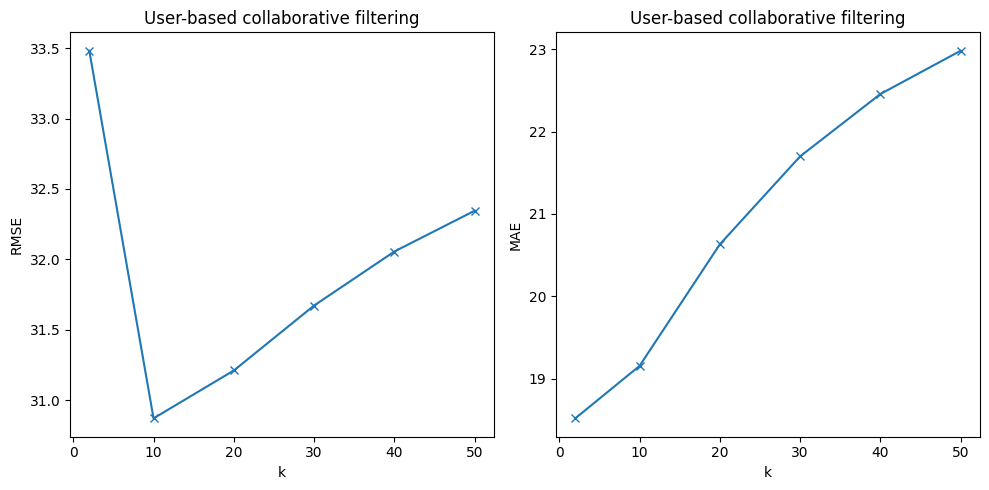

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].plot(k_values, rmse_set, marker='x')
axes[0].set_title('User-based collaborative filtering')
axes[0].set_xlabel('k')
axes[0].set_ylabel('RMSE')

axes[1].plot(k_values, mae_set, marker='x')
axes[1].set_title('User-based collaborative filtering')
axes[1].set_xlabel('k')
axes[1].set_ylabel('MAE')

plt.tight_layout()
plt.show()

## 1.2 Item-based collaborative filtering

In [4]:
k_values = [2, 10, 20, 30, 40, 50]
testset = validation_data.build_testset()

item_rmse_set = []
item_mae_set = []
for k in k_values:
  myUserKnn = surprise.KNNBasic(k=k, sim_options={'name': f'pearson', 'user_based': False})
  # Se entrena con set de entrenamiento
  myUserKnn.fit(train_data)
  # Se evalua con set de validacion
  predictions = myUserKnn.test(testset)

  item_rmse_set.append(accuracy.rmse(predictions))
  item_mae_set.append(accuracy.mae(predictions))

Computing the pearson similarity matrix...
Done computing similarity matrix.
RMSE: 25.7522
MAE:  13.2712
Computing the pearson similarity matrix...
Done computing similarity matrix.
RMSE: 22.5316
MAE:  12.4023
Computing the pearson similarity matrix...
Done computing similarity matrix.
RMSE: 22.0165
MAE:  12.3880
Computing the pearson similarity matrix...
Done computing similarity matrix.
RMSE: 21.8684
MAE:  12.4731
Computing the pearson similarity matrix...
Done computing similarity matrix.
RMSE: 21.8026
MAE:  12.5731
Computing the pearson similarity matrix...
Done computing similarity matrix.
RMSE: 21.7932
MAE:  12.6838


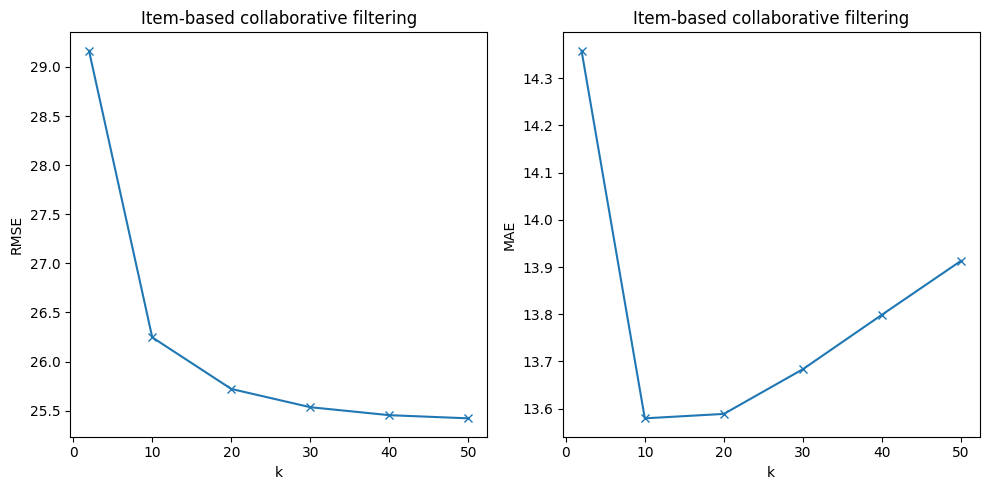

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].plot(k_values, item_rmse_set, marker='x')
axes[0].set_title('Item-based collaborative filtering')
axes[0].set_xlabel('k')
axes[0].set_ylabel('RMSE')

axes[1].plot(k_values, item_mae_set, marker='x')
axes[1].set_title('Item-based collaborative filtering')
axes[1].set_xlabel('k')
axes[1].set_ylabel('MAE')

plt.tight_layout()
plt.show()

## 1.3 FunkSVD

In [ ]:
# En la documentacion hacen referencia a FunkSVD
from surprise.prediction_algorithms.matrix_factorization import SVD

n_factors = [3, 25, 50, 75, 100]
testset = validation_data.build_testset()

funk_svd_rmse_set = []
funk_svd_mae_set = []
for factor in n_factors:
  svd_model = SVD(n_factors=factor, n_epochs=20)
  # Se entrena con set de entrenamiento
  svd_model.fit(train_data)
  # Se evalua con set de validacion
  predictions = svd_model.test(testset)

  funk_svd_rmse_set.append(accuracy.rmse(predictions))
  funk_svd_mae_set.append(accuracy.mae(predictions))

RMSE: 20.7816
MAE:  12.8967
RMSE: 22.4318
MAE:  13.9387
RMSE: 87.0226
MAE:  81.4953
RMSE: 87.0226
MAE:  81.4953
RMSE: 87.0226
MAE:  81.4953


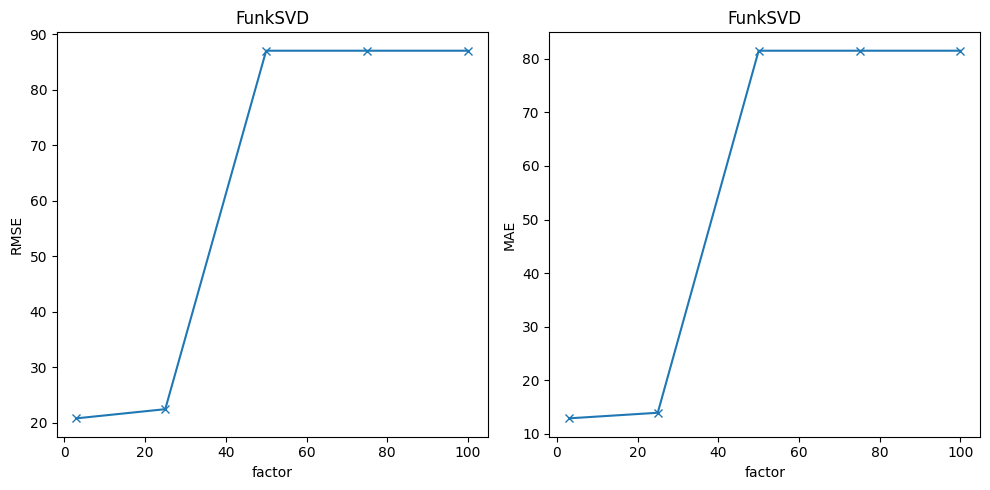

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].plot(n_factors, funk_svd_rmse_set, marker='x')
axes[0].set_title('FunkSVD')
axes[0].set_xlabel('factor')
axes[0].set_ylabel('RMSE')

axes[1].plot(n_factors, funk_svd_mae_set, marker='x')
axes[1].set_title('FunkSVD')
axes[1].set_xlabel('factor')
axes[1].set_ylabel('MAE')

plt.tight_layout()
plt.show()

## 1.4 SVD++ (Opcional)

In [ ]:
# Completar

# 2. Listas de recomendacion

In [4]:
# !pip install pyreclab --upgrade
import pyreclab

In [5]:
N = 10  

In [6]:
yahoo_artists = pd.read_csv("Datos/ydata_artists.txt", sep="\t", header=None)
yahoo_artists.columns = ["artist_id", "artist_name", "genre"]

In [7]:
# Codigo para evaluar métricas
import numpy as np

def recall_at_k(recs, gt, k):
    recalls = []
    for u in gt:
        if u not in recs:
            continue

        top_k = recs[u][:k]
        relevant = gt[u]

        if len(relevant) == 0:
            continue

        hits = len(set(top_k) & relevant)
        recalls.append(hits / len(relevant))

    return np.mean(recalls)


""" def ndcg_at_k(recs, gt, k):
    def dcg(rel):
        return sum([rel[i] / np.log2(i + 2) for i in range(len(rel))])

    ndcgs = []
    for u in gt:
        if u not in recs:
            continue
            
        top_k = recs[u][:k]
        relevant = gt[u]
        
        if len(relevant) == 0:
            continue
            
        rel = [1 if item in relevant else 0 for item in top_k]
        dcg_val = dcg(rel)
        
        num_relevant = len(relevant)
        ideal_rel = [1] * min(num_relevant, k) + [0] * (k - min(num_relevant, k))
        idcg_val = dcg(ideal_rel)
        
        ndcgs.append(dcg_val / idcg_val)

    return np.mean(ndcgs) """

def dcg_at_k(r, k):
    r = np.asarray(r)[:k]
    if r.size:
        return np.sum(np.subtract(np.power(2, r), 1) / np.log2(np.arange(2, r.size + 2)))
    return 0.


def ndcg_at_k(r, k):
    idcg = dcg_at_k(sorted(r, reverse=True), k)

    if not idcg:
        return 0.
    return dcg_at_k(r, k) / idcg

def map_at_k(recs, gt, k):
    aps = []

    for u in gt:
        if u not in recs:
            continue

        top_k = recs[u][:k]
        relevant = gt[u]

        if len(relevant) == 0:
            continue

        hits = 0
        sum_precisions = 0

        for i, item in enumerate(top_k):
            if item in relevant:
                hits += 1
                sum_precisions += hits / (i + 1)

        aps.append(sum_precisions / len(relevant))

    return np.mean(aps)

In [8]:
ground_truth = {}

threshold = 50
val_relevantes = yahoo_validation[yahoo_validation['rating'] >= threshold]

for _, row in val_relevantes.iterrows():
    user = row['user_id']
    item = row['artist_id']

    if user not in ground_truth:
        ground_truth[user] = set()

    ground_truth[user].add(item)

In [9]:
# Este código es de un práctico
def get_top_n(predictions, n=10):
    """Devuelve las N-mejores recomendaciones para cada usuario de un set de predicción.

    Args:
        predictions(lista de objetos Prediction): La lista de predicción obtenida del método test.
        n(int): El número de recomendaciónes por usuario

    Returns:
    Un diccionario donde las llaves son ids de usuario y los valores son listas de tuplas:
        [(item id, rating estimation), ...] de tamaño n.
    """

    # First map the predictions to each user.
    top_n = defaultdict(list)
    for uid, iid, true_r, est, _ in predictions:
        top_n[uid].append((iid, est))

    # Then sort the predictions for each user and retrieve the k highest ones.
    for uid, user_ratings in top_n.items():
        user_ratings.sort(key=lambda x: x[1], reverse=True)
        top_n[uid] = user_ratings[:n]

    return top_n

In [10]:
# Métricas diversidad y novedad
def cant_estilos_distintos(recs, yahoo_artists):
    suma = 0
    for user_id in recs:
        recs_u = pd.Series(recs[user_id], name="artist_id")
        recs_genre = pd.merge(recs_u, yahoo_artists, how="left")
        suma += len(recs_genre["genre"].unique())
    return suma / len(recs)

def self_information(recs, yahoo_train):
    total_usuarios_train = yahoo_train['user_id'].nunique()
    vistas_por_artista = yahoo_train.groupby('artist_id')['user_id'].nunique()
    pop_i = (vistas_por_artista / total_usuarios_train)
    
    sum_u = 0
    for user_id in recs:
        pop_i_usuario = pop_i[pop_i.index.isin(recomendaciones_random[user_id])] 
        log_pop = np.log(1 / pop_i_usuario)
        sum_i = np.sum(log_pop)
        sum_u += sum_i

    return sum_u / len(recs)

## 2.1 Random

In [11]:
usuarios = yahoo_validation['user_id'].unique()
recomendaciones_random = {}

ids_artistas = pd.concat([yahoo_validation['artist_id'], yahoo_train['artist_id']])
ids_artistas.drop_duplicates(keep="first", inplace=True)

for user_id in usuarios:
    vistos_por_usuario = yahoo_train[yahoo_train['user_id'] == user_id]['artist_id']
    ids_artistas_filtrados = ids_artistas[~ids_artistas.isin(vistos_por_usuario)]

    random_items = ids_artistas_filtrados.sample(n=N).tolist()
    recomendaciones_random[int(user_id)] = random_items

In [ ]:
recall = recall_at_k(recomendaciones_random, ground_truth, N)
ndcg = ndcg_at_k(recomendaciones_random, ground_truth, N)
map_k = map_at_k(recomendaciones_random, ground_truth, N)

print(f"Recall@{N}: {recall}")
print(f"nDCG@{N}: {ndcg}")
print(f"MAP@{N}: {map_k}")

print("Métricas Diversidad: ", cant_estilos_distintos(recomendaciones_random, yahoo_artists))
print("Métrica Novedad: ", self_information(recomendaciones_random, yahoo_train))

IndexError: too many indices for array: array is 0-dimensional, but 1 were indexed

## 2.2 Most Popular

In [9]:
popularidad = yahoo_train.groupby('artist_id')['user_id'].count()
artistas_mas_populares = popularidad.sort_values(ascending=False).index.tolist()

recomendaciones_most_popular = {}
usuarios_val = yahoo_validation['user_id'].unique()

for user_id in usuarios_val:
    vistos_por_usuario = set(yahoo_train[yahoo_train['user_id'] == user_id]['artist_id'])
    
    recs_usuario = []
    for artista in artistas_mas_populares:
        if artista not in vistos_por_usuario:
            recs_usuario.append(artista)

        if len(recs_usuario) == N:
            break
    
    recomendaciones_most_popular[int(user_id)] = recs_usuario

In [ ]:
recall_mp = recall_at_k(recomendaciones_most_popular, ground_truth, N)
ndcg_mp = ndcg_at_k(recomendaciones_most_popular, ground_truth, N)
map_k_mp = map_at_k(recomendaciones_most_popular, ground_truth, N)

print(f"Recall@{N}: {recall_mp}")
print(f"nDCG@{N}: {ndcg_mp}")
print(f"MAP@{N}: {map_k_mp}")

print("Métricas Diversidad: ", cant_estilos_distintos(recomendaciones_most_popular, yahoo_artists))
print("Métrica Novedad: ", self_information(recomendaciones_most_popular, yahoo_train))

Recall@10: 0.025243494863023838
nDCG@10: 0.45442978166873943
MAP@10: 0.006772209425938323


## 2.3 Item-based collaborative filtering

In [ ]:
# Gemini me dice que hay un error en este código, porque no considera todas las recomendaciones posibles sino solo las del cjto de validación
k_values = [2, 10, 20, 30, 40, 50]
testset = validation_data.build_testset()

Recall_values = []
nDCG_values = []
MAP_values = []
diversity_values = []
self_info_values = []

for k in k_values:
  myUserKnn = surprise.KNNBasic(k=k, sim_options={'name': f'pearson', 'user_based': False})
  # Se entrena con set de entrenamiento
  myUserKnn.fit(train_data)
  # Se evalua con set de validacion
  predictions = myUserKnn.test(testset)
  top_n = get_top_n(predictions, n=N)

  recomendaciones_knn = {}
  for uid, user_ratings in top_n.items():
    recomendaciones_knn[int(uid)] = [int(iid) for (iid, est) in user_ratings]

  Recall_values.append(recall_at_k(recomendaciones_knn, ground_truth, N))
  nDCG_values.append(ndcg_at_k(recomendaciones_knn, ground_truth, N))
  MAP_values.append(map_at_k(recomendaciones_knn, ground_truth, N))

  diversity_values.append(cant_estilos_distintos(recomendaciones_knn, yahoo_artists))
  self_info_values.append(self_information(recomendaciones_knn, yahoo_train))


Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.


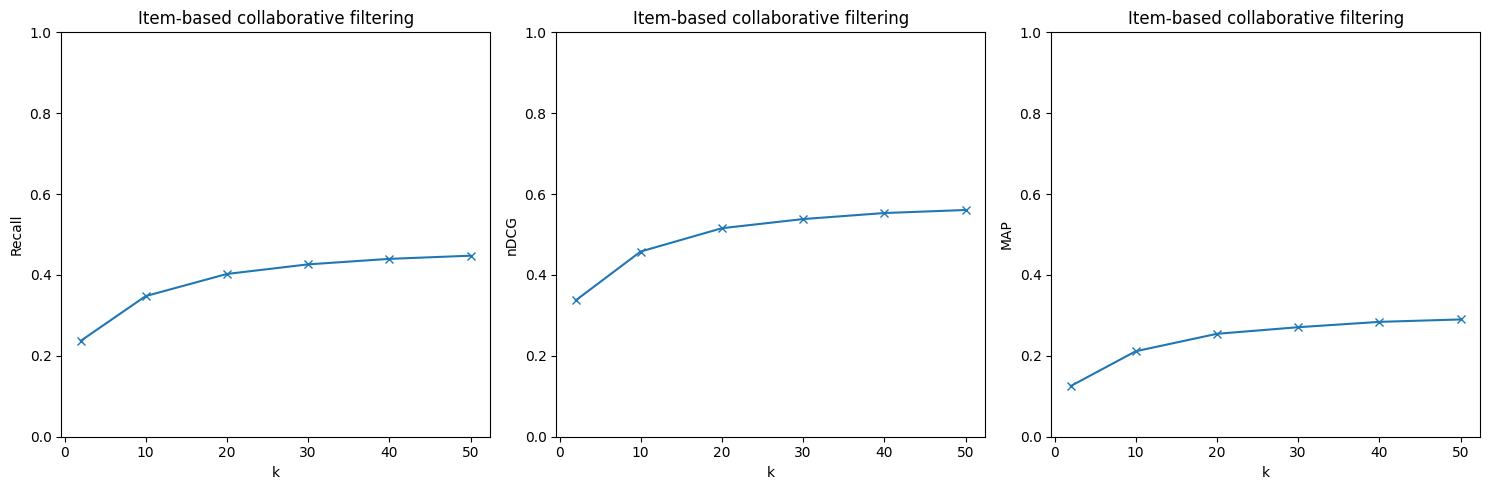

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(k_values, Recall_values, marker='x')
axes[0].set_title('Item-based collaborative filtering')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Recall')
axes[0].set_ylim(0, 1)

axes[1].plot(k_values, nDCG_values, marker='x')
axes[1].set_title('Item-based collaborative filtering')
axes[1].set_xlabel('k')
axes[1].set_ylabel('nDCG')
axes[1].set_ylim(0, 1)

axes[2].plot(k_values, MAP_values, marker='x')
axes[2].set_title('Item-based collaborative filtering')
axes[2].set_xlabel('k')
axes[2].set_ylabel('MAP')
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.show()

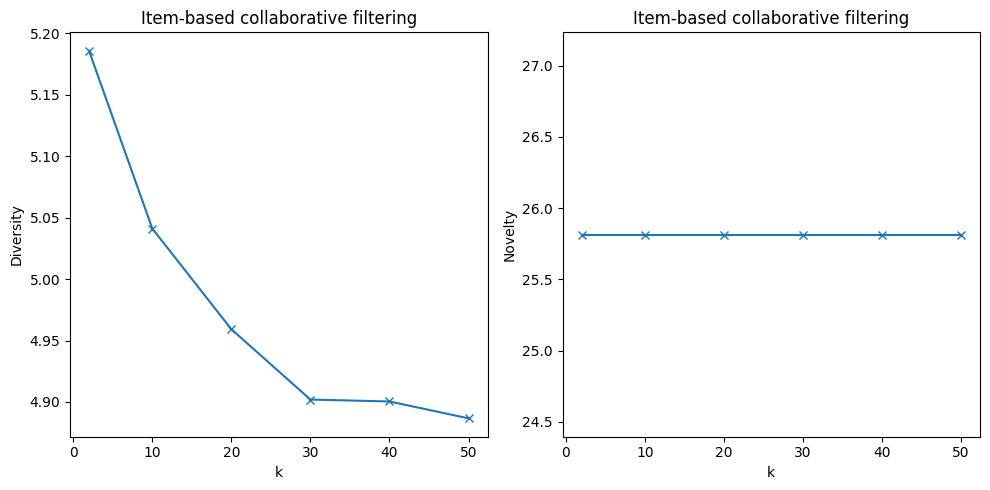

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].plot(k_values, diversity_values, marker='x')
axes[0].set_title('Item-based collaborative filtering')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Diversity')
#axes[0].set_ylim(0, 1)

axes[1].plot(k_values, self_info_values, marker='x')
axes[1].set_title('Item-based collaborative filtering')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Novelty')
#axes[1].set_ylim(0, 1)


plt.tight_layout()
plt.show()

## 2.4 FunkSVD

Problema: No estoy seguro como calcular Recall@K.

In [ ]:
# Definicion de objeto svd
svd = pyreclab.SVD(dataset='Datos/ydata_train.txt',   # /content/Datos/ydata_train.txt
                   dlmchar=b'\t',
                   header=False,
                   usercol=0,
                   itemcol=1,
                   ratingcol=2)

# Entrenamiento del modelo
svd.train(factors=100, maxiter=100, lr=0.01, lamb=0.1)

In [ ]:
# Testing de recomendaciones
recommendList, maprec, ndcg = svd.testrec(input_file='/content/Datos/ydata_val.txt',
                                          dlmchar=b'\t',
                                          header=False,
                                          usercol=0,
                                          itemcol=1,
                                          ratingcol=2,
                                          topn=N,
                                          relevance_threshold=2,
                                          includeRated=False)

recomendaciones_funk_svd = {}

for uid, items in recommendList.items():
    # Convertimos strings a enteros para que calcen con el ground_truth
    recomendaciones_funk_svd[int(uid)] = [int(iid) for iid in items]

print('MAP: {}\nNDCG@{}: {}'.format(maprec, N, ndcg))
print(f"Recall@{N}: {recall_at_k(recomendaciones_funk_svd, ground_truth, N):.4f}")

MAP: 0.013124817200185301
NDCG@10: 0.0049154801091752165


In [55]:
from surprise.prediction_algorithms.matrix_factorization import SVD

n_factors = [3, 25, 50, 75, 100]
testset = validation_data.build_testset()

Recall_values = []
nDCG_values = []
MAP_values = []
diversity_values = []
self_info_values = []

for factor in n_factors:
  svd_model = SVD(n_factors=factor, n_epochs=20)
  # Se entrena con set de entrenamiento
  svd_model.fit(train_data)
  # Se evalua con set de validacion
  predictions = svd_model.test(testset)
  top_n = get_top_n(predictions, n=N)

  recomendaciones_svd = {}
  for uid, user_ratings in top_n.items():
    # Extraemos solo el item_id (la posición 0 de la tupla) y lo pasamos a entero
    recomendaciones_svd[int(uid)] = [int(iid) for (iid, est) in user_ratings]

  Recall_values.append(recall_at_k(recomendaciones_svd, ground_truth, N))
  nDCG_values.append(ndcg_at_k(recomendaciones_svd, ground_truth, N))
  MAP_values.append(map_at_k(recomendaciones_svd, ground_truth, N))
  diversity_values.append(cant_estilos_distintos(recomendaciones_svd, yahoo_artists))
  self_info_values.append(self_information(recomendaciones_svd, yahoo_train))


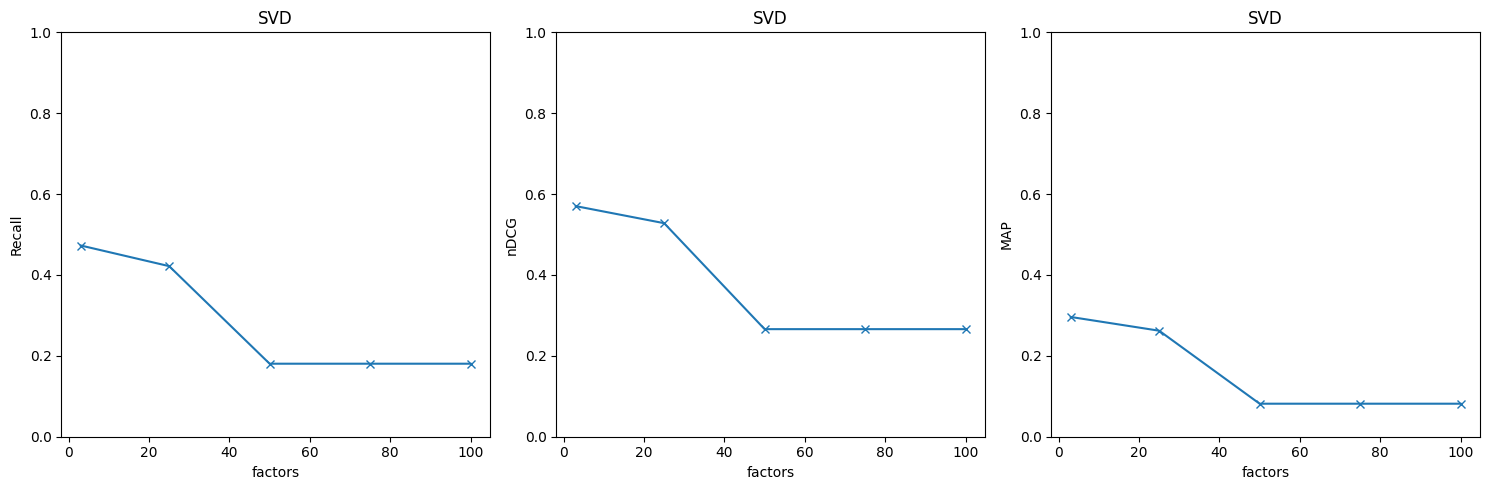

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(n_factors, Recall_values, marker='x')
axes[0].set_title('SVD')
axes[0].set_xlabel('factors')
axes[0].set_ylabel('Recall')
axes[0].set_ylim(0, 1)

axes[1].plot(n_factors, nDCG_values, marker='x')
axes[1].set_title('SVD')
axes[1].set_xlabel('factors')
axes[1].set_ylabel('nDCG')
axes[1].set_ylim(0, 1)

axes[2].plot(n_factors, MAP_values, marker='x')
axes[2].set_title('SVD')
axes[2].set_xlabel('factors')
axes[2].set_ylabel('MAP')
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.show()

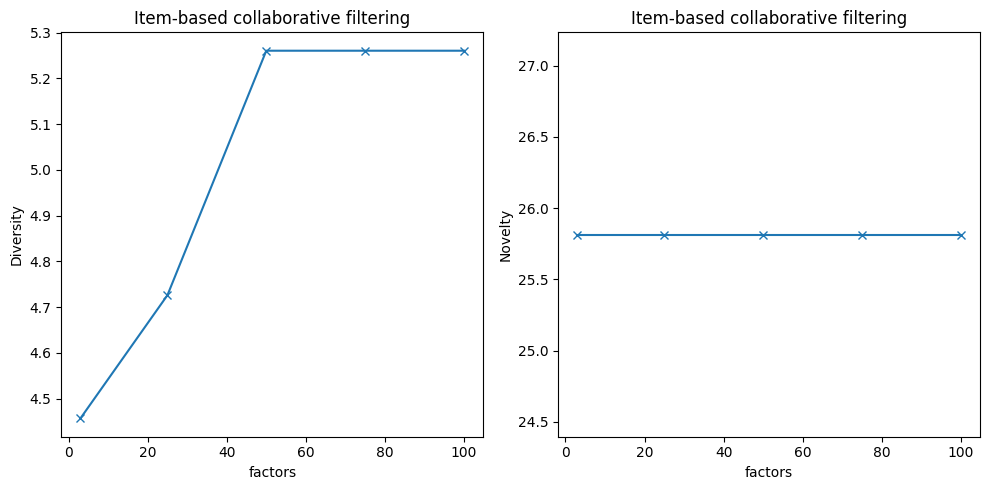

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].plot(n_factors, diversity_values, marker='x')
axes[0].set_title('Item-based collaborative filtering')
axes[0].set_xlabel('factors')
axes[0].set_ylabel('Diversity')
#axes[0].set_ylim(0, 1)

axes[1].plot(n_factors, self_info_values, marker='x')
axes[1].set_title('Item-based collaborative filtering')
axes[1].set_xlabel('factors')
axes[1].set_ylabel('Novelty')
#axes[1].set_ylim(0, 1)


plt.tight_layout()
plt.show()

Codigo bruno

In [ ]:
for c, user in enumerate(yahoo_validation['user_id'].to_numpy()):
    print(f'user {str(user)}: {c}/{yahoo_validation.shape[0]}')
    recall = svd.recall(str(user),
                        recommendList[str(user)],
                        topn = 10,
                        relevance_threshold = 0,
                        include_rated = False)
    print(recall)

user 1641538: 0/152424


RuntimeError: Test data not found

In [ ]:
## Recall@K

def recall_at_k(recommendations, ground_truth, k):
    recalls = []

    for user in ground_truth:
        #if user not in recommendations:
        #    continue

        recs = recommendations[user][:k]
        relevant_items = ground_truth[user]

        if len(relevant_items) == 0:
            continue

        hits = len(set(recs) & relevant_items)
        recall = hits / len(relevant_items)
        recalls.append(recall)

    return sum(recalls) / len(recalls)